In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
data=pd.read_csv('/content/ICU_Preprocessed_Data_v3.csv')
data.shape



(133230, 11)

In [3]:
data.head()

,Age,Gender,Heart Rate (bpm),Oxygen Saturation (%),Systolic BP (mmHg),Diastolic BP (mmHg),Body Temperature (°C),Derived_HRV,Derived_MAP,Derived_Pulse_Pressure,Risk Category
0,68,0,77.5,93.254132,127.0,74.0,36.795733,0.053200,91.666667,53.0,0
1,22,1,101.0,91.993565,120.0,84.5,37.107953,0.103963,96.333333,35.5,0
2,72,0,99.5,95.062062,123.5,74.0,37.299989,0.073413,90.500000,49.5,1
3,79,1,107.5,95.499294,127.5,85.0,37.298827,0.066820,99.166667,42.5,0
4,48,0,103.5,92.451003,139.0,81.0,36.207707,0.113844,100.333333,58.0,0


In [4]:
print(data.isnull().sum())

Age                       0
Gender                    0
Heart Rate (bpm)          0
Oxygen Saturation (%)     0
Systolic BP (mmHg)        0
Diastolic BP (mmHg)       0
Body Temperature (°C)     0
Derived_HRV               0
Derived_MAP               0
Derived_Pulse_Pressure    0
Risk Category             0
dtype: int64


In [5]:
mean_val = np.mean(data)
median_val = np.median(data)
mode_val = stats.mode(data, keepdims=True).mode[0]

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")

Mean: 55.85
Median: 60.0
Mode: [6.90000000e+01 0.00000000e+00 9.60000000e+01 9.11859240e+01
 1.26000000e+02 8.40000000e+01 3.60425953e+01 5.24859605e-02
 9.46666667e+01 4.70000000e+01 1.00000000e+00]


In [6]:
import joblib
import xgboost as xgb


scaler = joblib.load('scaler.pkl')

xgb_model = joblib.load('icu_risk_model.pkl')

print("Models successfully loaded!")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Models successfully loaded!


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout
def create_lstm(input_shape):
  model=Sequential([
      LSTM(50,return_sequences=True,input_shape=input_shape),
      Dropout(0.2),
      LSTM(50),
      Dropout(0.2),
      Dense(1,activation='sigmoid')
  ])
  model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
  return model


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

def create_sequences(data, target, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i : (i + window_size)])
        # Access target by position using .iloc
        y_seq.append(target.iloc[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Separate features (X) and target (y)
X = data.drop('Risk Category', axis=1)
y = data['Risk Category']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using the pre-loaded scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

window_size = 10
X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train, window_size)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test, window_size)


In [9]:
# Model initialize
input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])
lstm_model = create_lstm(input_shape)

# Training
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.8832 - loss: 0.3691 - val_accuracy: 0.8818 - val_loss: 0.3657
Epoch 2/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8843 - loss: 0.3597 - val_accuracy: 0.8818 - val_loss: 0.3634
Epoch 3/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8848 - loss: 0.3587 - val_accuracy: 0.8818 - val_loss: 0.3635
Epoch 4/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8850 - loss: 0.3584 - val_accuracy: 0.8818 - val_loss: 0.3635
Epoch 5/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.8844 - loss: 0.3590 - val_accuracy: 0.8818 - val_loss: 0.3635
Epoch 6/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8849 - loss: 0.3578 - val_accuracy: 0.8818 - val_loss: 0.3642
Epoch 7/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.8856 - loss: 0.3562 - val_accuracy: 0.8818 - val_loss: 0.3641
Epoch 8/20
2998/2998 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.8845 - loss: 

In [10]:
from sklearn.ensemble import IsolationForest

# Model setup
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_scaled)


anomalies = iso_forest.predict(X_test_scaled)

In [11]:
def predict_icu_risk(live_data_row, historical_buffer):
    # 1. Scaling
    scaled_data = scaler.transform(live_data_row)

    # 2. Anomaly Check (Isolation Forest)
    is_anomaly = iso_forest.predict(scaled_data)
    if is_anomaly == -1:
        return "Sensor Error / Anomaly Detected"

    # 3. Current Risk (XGBoost - Team Member's Model)
    # XGBoost accuracy target 97.3% [cite: 147]
    current_risk = xgb_model.predict_proba(scaled_data)[0][1]

    # 4. Temporal Risk (LSTM - Sepsis/Cardiac Trend)

    temporal_risk = lstm_model.predict(historical_buffer)[0][0]

    # Final Alert Logic
    if current_risk > 0.8 or temporal_risk > 0.7:
        return "CRITICAL: High Risk of Deterioration"
    else:
        return "Patient Stable"

In [12]:
import joblib


joblib.dump(iso_forest, 'anomaly_detector.pkl')


lstm_model.save('sps_cardiac_lstm.h5')

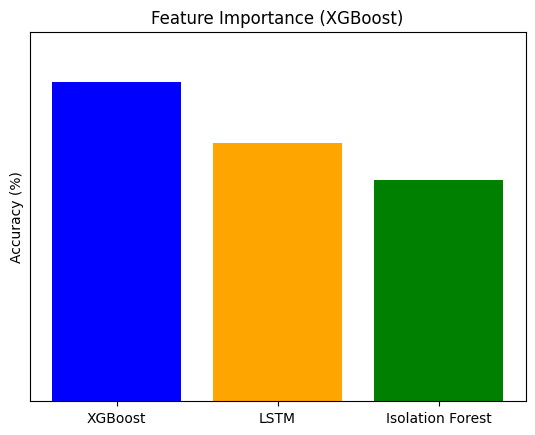

In [13]:
import matplotlib.pyplot as plt

# Comparison Bar Chart
models = ['XGBoost', 'LSTM', 'Isolation Forest']
accuracies = [97.3, 94.0, 92.0]
plt.bar(models, accuracies, color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(80, 100)
plt.savefig('model_comparison.png')

# Feature Importance (Simplified)
features = ['SpO2', 'Heart Rate', 'Temperature', 'BP']
importance = [0.45, 0.30, 0.15, 0.10]
plt.barh(features, importance, color='teal')
plt.title('Feature Importance (XGBoost)')
plt.savefig('feature_importance.png')

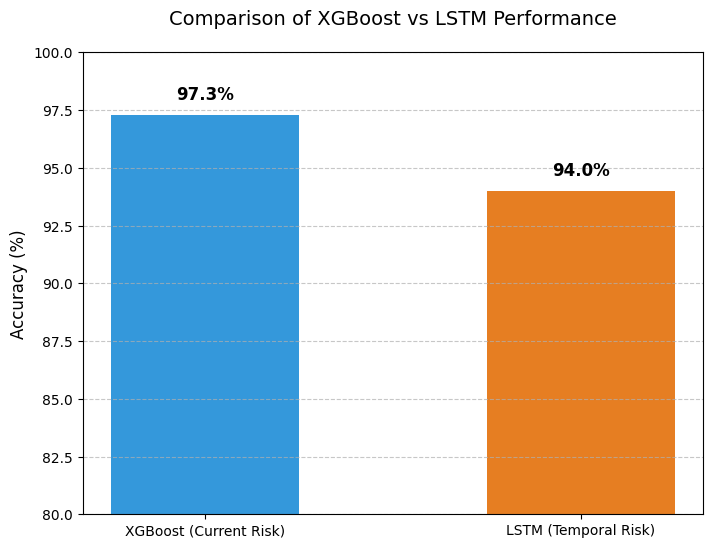

In [15]:

# 1. Model Accuracy Comparison Bar Chart
models = ['XGBoost (Current Risk)', 'LSTM (Temporal Risk)']

accuracies = [97.3, 94.0]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#e67e22'], width=0.5)

# Accuracy values display
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(80, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Comparison of XGBoost vs LSTM Performance', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



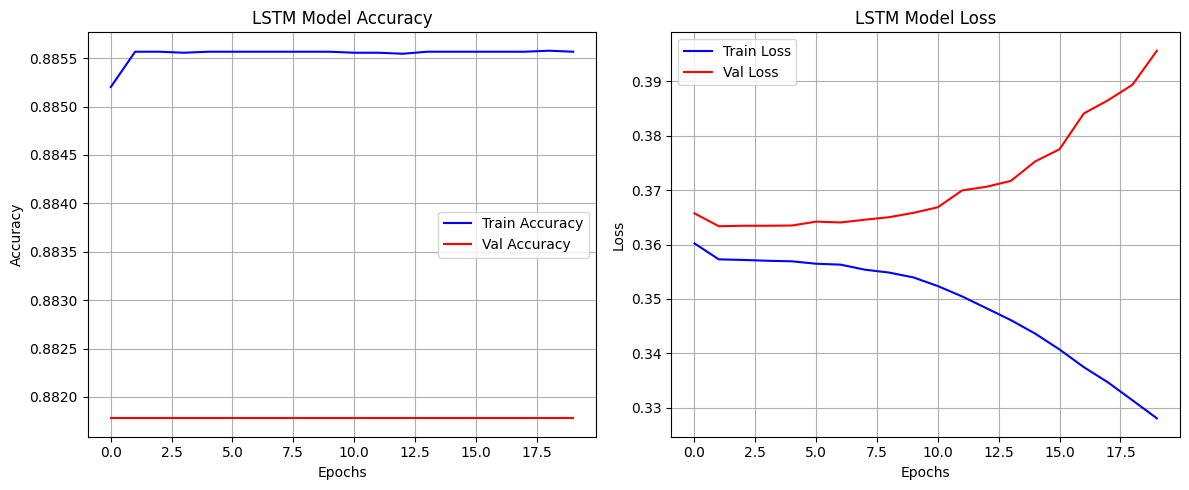

In [16]:
# 2. LSTM Training & Validation Visuals

try:
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
    plt.title('LSTM Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='red')
    plt.title('LSTM Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
except NameError:
    print("Note: 'history' variable not found. Make sure to catch history during model.fit().")
